In [4]:
from qiskit.circuit.random import random_circuit
from qiskit.quantum_info import Operator, average_gate_fidelity
from qiskit.transpiler import PassManager
from gulps import GateInvariants, GulpsDecomposer, GulpsDecompositionPass
from gulps.config import GulpsConfig
from gulps.core.coverage import weyl_linspace
from tests.fixtures.isas import get_random_circuit_isas
from qiskit.circuit.library import CXGate, iSwapGate
from gulps.core.isa import DiscreteISA

FIDELITY_TOL = 1 - 1e-8
N_SEEDS = 5
N_WEYL = 256

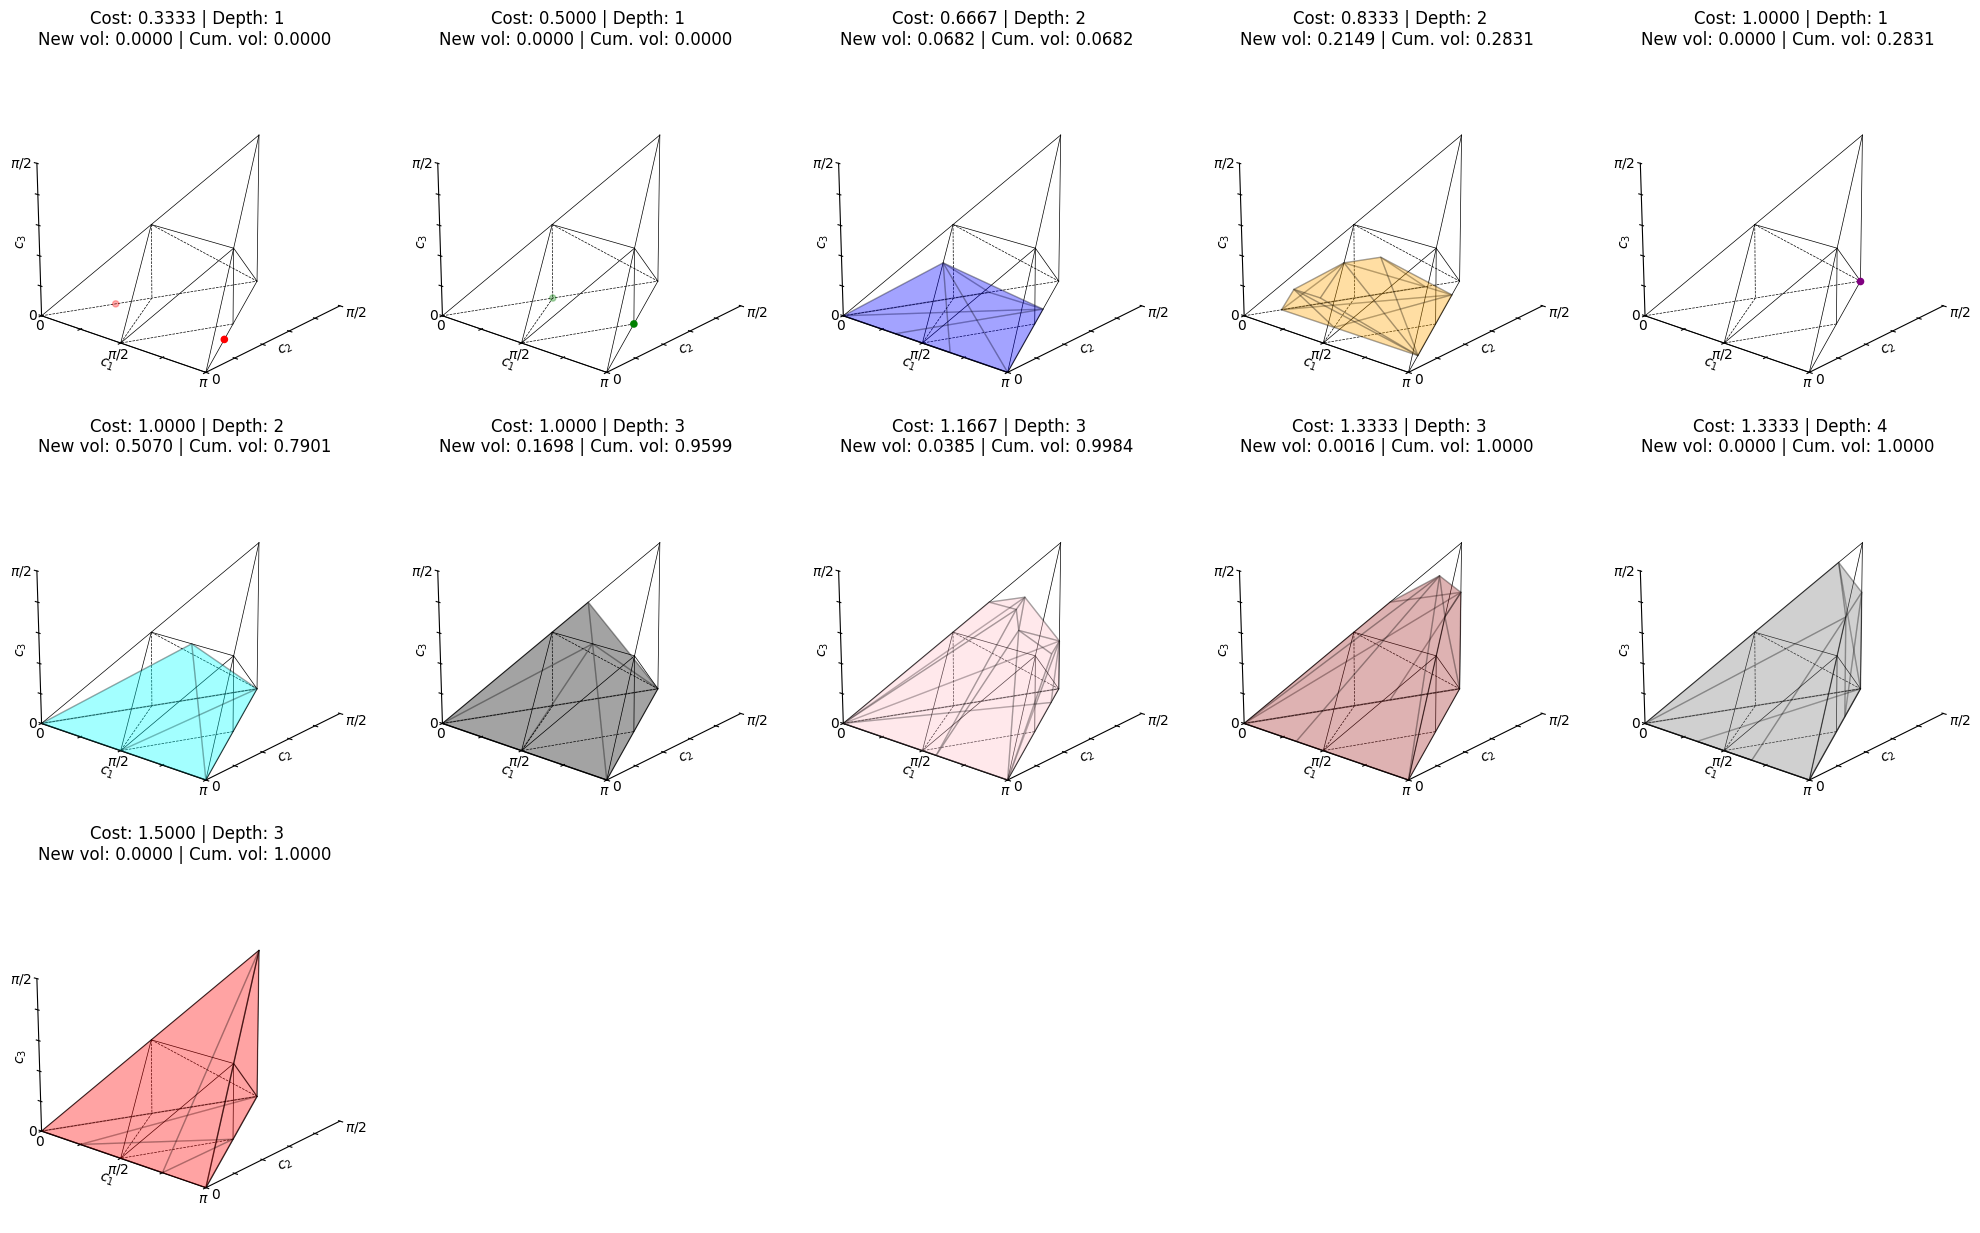

Coverage Set Statistics (Haar-averaged over SU(4))
Expected Cost:  0.948419
  → Average cost per random 2-qubit unitary

Expected Depth: 2.209916
  → Average number of 2-qubit gates


In [ ]:
isa = [
    (iSwapGate(), 1.0, "iswap"),
    (iSwapGate().power(1 / 2), 1 / 2, "sqrt2iswap"),
    (iSwapGate().power(1 / 3), 1 / 3, "sqrt3iswap"),
]
gate_set, costs, names = zip(*isa)
isa = DiscreteISA(gate_set, costs, names, precompute_polytopes=True)
decomposer = GulpsDecomposer(isa=isa, config_options=GulpsConfig())


gulps_pm = PassManager(
    [
        GulpsDecompositionPass(decomposer),
    ]
)

if hasattr(decomposer.isa, "coverage_set"):
    from gulps.core.coverage import coverage_report

    report = coverage_report(decomposer.isa.coverage_set)

(<Figure size 640x480 with 1 Axes>,
 <Axes3D: xlabel='$c_1$', ylabel='$c_2$', zlabel='$c_3$'>)

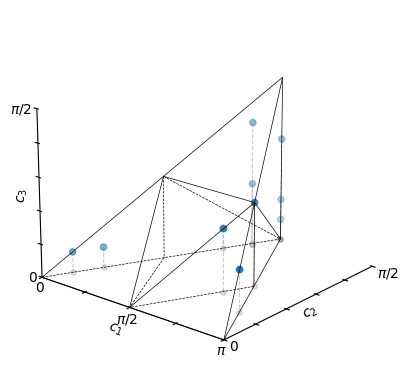

In [ ]:
import warnings

# detect if decomposer raised a UserWarning
warnings.filterwarnings("error")

failed_points = []
for weyl_pt in weyl_linspace(N_WEYL):
    target = GateInvariants.from_weyl(weyl_pt)
    try:
        circuit = decomposer(target.unitary)
        fid = average_gate_fidelity(Operator(target.unitary), Operator(circuit))
        assert fid > FIDELITY_TOL, (
            f"Fidelity {fid:.8f} at Weyl point ({weyl_pt[0]:.3f}, {weyl_pt[1]:.3f}, {weyl_pt[2]:.3f})"
        )
    except Exception:
        failed_points.append(target)

from gulps.viz.invariant_viz import scatter_plot

scatter_plot(failed_points)